# Low-Resource Cross-Lingual Embedding Adaptation

**Goal:** Adapt a multilingual sentence encoder to Hindi-English using a deliberately small parallel corpus, then measure whether cross-lingual semantic retrieval improves.

This project includes:
- a pretrained baseline and a fine-tuned model;
- contrastive learning with in-batch negatives;
- bidirectional Recall@1, Recall@5, Recall@10, and MRR;
- phrase-level linguistic probes;
- UMAP visualization and retrieval error analysis;
- exportable model and metrics.

> In Colab, select **Runtime > Change runtime type > T4 GPU** before running all cells.

In [ ]:
%pip install -q -U "sentence-transformers>=5.0,<6" "datasets>=3.0,<5" "accelerate>=1.0" umap-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 22.8 MB/s eta 0:00:00


In [ ]:
import json, os, random, shutil, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import Dataset, load_dataset
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
    losses,
)
from sentence_transformers.training_args import BatchSamplers
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import umap.umap_ as umap

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

LANG = "hi"                 # Hindi. Try: bn, ta, te, ur, mr (if available in OPUS-100)
LANG_NAME = "Hindi"
DATASET_CONFIG = f"en-{LANG}"
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
TRAIN_SIZE = 8_000          # Low-resource simulation
DEV_SIZE = 500
TEST_SIZE = 1_000
EPOCHS = 1                  # Increase to 2 for a stronger experiment
BATCH_SIZE = 64             # Reduce to 32 if GPU memory is limited
OUTPUT_DIR = Path("low_resource_embedding_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print(f"Experiment: English <-> {LANG_NAME} | train pairs: {TRAIN_SIZE:,}")

/tmp/ipykernel_3258/1520343700.py:10: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (
/tmp/ipykernel_3258/1520343700.py:16: DeprecationWarning: Importing from 'sentence_transformers.training_args' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.training_args' instead.
  from sentence_transformers.training_args import BatchSamplers


Device: Tesla T4
Experiment: English <-> Hindi | train pairs: 8,000


## 1. Load and audit a small parallel corpus

OPUS-100 is English-centric and provides held-out validation/test splits. We use only 8,000 training pairs to simulate a constrained-data setting.

In [ ]:
raw = load_dataset("Helsinki-NLP/opus-100", DATASET_CONFIG)
print(raw)
print("Example:", raw["train"][0]["translation"])

def valid_pair(example):
    pair = example["translation"]
    en = pair.get("en", "").strip()
    xx = pair.get(LANG, "").strip()
    return 5 <= len(en) <= 300 and 5 <= len(xx) <= 300

def prepare_split(split, size, seed):
    split = split.filter(valid_pair)
    size = min(size, len(split))
    split = split.shuffle(seed=seed).select(range(size))
    rows = {
        "anchor": [x["en"].strip() for x in split["translation"]],
        "positive": [x[LANG].strip() for x in split["translation"]],
    }
    return Dataset.from_dict(rows)

train_ds = prepare_split(raw["train"], TRAIN_SIZE, SEED)
dev_ds = prepare_split(raw["validation"], DEV_SIZE, SEED + 1)
test_ds = prepare_split(raw["test"], TEST_SIZE, SEED + 2)

audit = pd.DataFrame({
    "split": ["train", "dev", "test"],
    "pairs": [len(train_ds), len(dev_ds), len(test_ds)],
    "avg_en_chars": [np.mean([len(x) for x in d["anchor"]]) for d in [train_ds, dev_ds, test_ds]],
    f"avg_{LANG}_chars": [np.mean([len(x) for x in d["positive"]]) for d in [train_ds, dev_ds, test_ds]],
})
display(audit.round(1))
display(pd.DataFrame(train_ds[:3]))

README.md:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

en-hi/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

en-hi/train-00000-of-00001.parquet:   0%|          | 0.00/65.2M [00:00<?, ?B/s]

en-hi/validation-00000-of-00001.parquet:   0%|          | 0.00/247k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/534319 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2000 [00:00<?, ? examples/s]

,split,pairs,avg_en_chars,avg_hi_chars
0,train,8000,55.2,57.9
1,dev,500,52.7,55.0
2,test,1000,55.2,56.6


,anchor,positive
0,Active,क्रिया (_A)
1,"Hey, Jake.",~ हे याकूब.
2,- No choo-choo!,- चू-चू नहीं!


## 2. Bidirectional retrieval evaluation

For each sentence, the correct translation must be retrieved from all candidates. This is stricter and more useful than reporting only average cosine similarity.

In [ ]:
def retrieval_metrics(similarity):
    order = np.argsort(-similarity, axis=1)
    ranks = np.array([np.where(order[i] == i)[0][0] + 1 for i in range(len(order))])
    return {
        "R@1": float(np.mean(ranks <= 1)),
        "R@5": float(np.mean(ranks <= 5)),
        "R@10": float(np.mean(ranks <= 10)),
        "MRR": float(np.mean(1.0 / ranks)),
        "median_rank": float(np.median(ranks)),
    }, ranks

def evaluate_model(model, dataset, label, batch_size=128):
    en = dataset["anchor"]
    xx = dataset["positive"]
    en_emb = model.encode(en, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=True)
    xx_emb = model.encode(xx, batch_size=batch_size, normalize_embeddings=True, show_progress_bar=True)
    sim = en_emb @ xx_emb.T
    en_to_xx, ranks_forward = retrieval_metrics(sim)
    xx_to_en, ranks_backward = retrieval_metrics(sim.T)
    row = {"model": label}
    for key, value in en_to_xx.items(): row[f"en_to_{LANG}_{key}"] = value
    for key, value in xx_to_en.items(): row[f"{LANG}_to_en_{key}"] = value
    row["mean_R@1"] = (en_to_xx["R@1"] + xx_to_en["R@1"]) / 2
    row["mean_MRR"] = (en_to_xx["MRR"] + xx_to_en["MRR"]) / 2
    row["paired_cosine"] = float(np.mean(np.diag(sim)))
    details = {
        "en_emb": en_emb, "xx_emb": xx_emb, "sim": sim,
        "forward_ranks": ranks_forward, "backward_ranks": ranks_backward,
    }
    return row, details

baseline_model = SentenceTransformer(MODEL_NAME)
baseline_row, baseline_details = evaluate_model(baseline_model, test_ds, "pretrained_baseline")
display(pd.DataFrame([baseline_row]).round(4))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

,model,en_to_hi_R@1,en_to_hi_R@5,en_to_hi_R@10,en_to_hi_MRR,en_to_hi_median_rank,hi_to_en_R@1,hi_to_en_R@5,hi_to_en_R@10,hi_to_en_MRR,hi_to_en_median_rank,mean_R@1,mean_MRR,paired_cosine
0,pretrained_baseline,0.77,0.867,0.887,0.8165,1.0,0.745,0.856,0.873,0.7925,1.0,0.7575,0.8045,0.7431


## 3. Contrastive adaptation

`MultipleNegativesRankingLoss` treats every other translation in a batch as a negative. A no-duplicates sampler makes those in-batch negatives cleaner.

In [ ]:
model = SentenceTransformer(MODEL_NAME)
train_loss = losses.MultipleNegativesRankingLoss(model)

training_args = SentenceTransformerTrainingArguments(
    output_dir=str(OUTPUT_DIR / "checkpoints"),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    bf16=False,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=1,
    logging_steps=25,
    report_to=[],
    run_name=f"low-resource-en-{LANG}-embeddings",
    seed=SEED,
)

trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    loss=train_loss,
)
trainer.train()

FINAL_MODEL_DIR = OUTPUT_DIR / f"minilm-en-{LANG}-adapted"
model.save_pretrained(str(FINAL_MODEL_DIR))
print("Saved model to", FINAL_MODEL_DIR)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


Step,Training Loss,Validation Loss
100,0.317371,0.308825
125,0.337094,0.306822


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to low_resource_embedding_outputs/minilm-en-hi-adapted


## 4. Compare baseline and adapted model

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

,model,en_to_hi_R@1,en_to_hi_R@5,hi_to_en_R@1,hi_to_en_R@5,mean_R@1,mean_MRR,paired_cosine
0,pretrained_baseline,0.770,0.867,0.745,0.856,0.7575,0.8045,0.7431
1,contrastive_adapted,0.862,0.930,0.840,0.923,0.8510,0.8854,0.7556


Absolute mean Recall@1 improvement: +9.35 percentage points


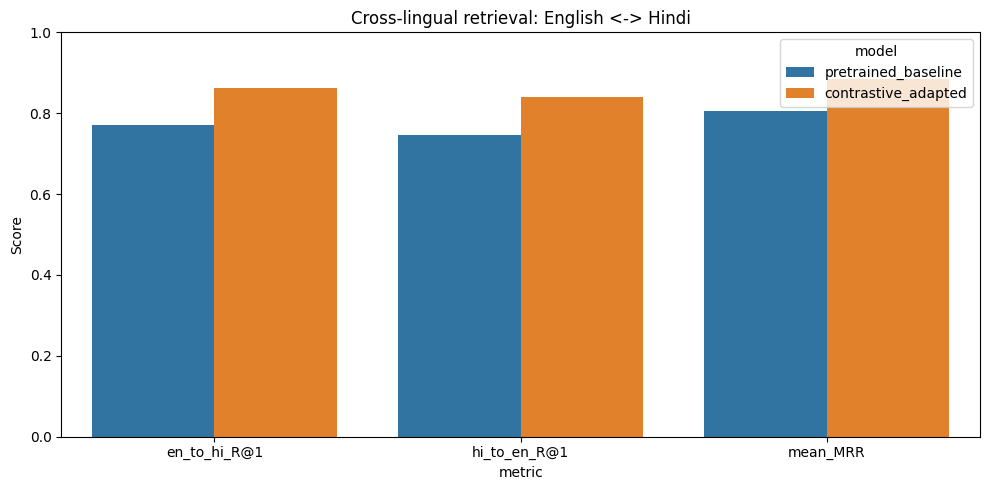

In [ ]:
adapted_row, adapted_details = evaluate_model(model, test_ds, "contrastive_adapted")
results = pd.DataFrame([baseline_row, adapted_row])

metric_cols = [
    "model", f"en_to_{LANG}_R@1", f"en_to_{LANG}_R@5",
    f"{LANG}_to_en_R@1", f"{LANG}_to_en_R@5", "mean_R@1", "mean_MRR", "paired_cosine"
]
display(results[metric_cols].round(4))

improvement = 100 * (adapted_row["mean_R@1"] - baseline_row["mean_R@1"])
print(f"Absolute mean Recall@1 improvement: {improvement:+.2f} percentage points")

plot_df = results.melt(
    id_vars="model",
    value_vars=[f"en_to_{LANG}_R@1", f"{LANG}_to_en_R@1", "mean_MRR"],
    var_name="metric", value_name="score"
)
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title(f"Cross-lingual retrieval: English <-> {LANG_NAME}")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "retrieval_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Phrase-level linguistic probes

This small qualitative probe checks whether common semantic concepts retrieve their translation. It is not a substitute for a large lexical benchmark, but it makes model behavior interpretable.

In [ ]:
LEXICON = [
    ("water", "पानी"), ("family", "परिवार"), ("education", "शिक्षा"),
    ("health", "स्वास्थ्य"), ("government", "सरकार"), ("computer", "कंप्यूटर"),
    ("beautiful", "सुंदर"), ("freedom", "स्वतंत्रता"), ("science", "विज्ञान"),
    ("village", "गाँव"), ("market", "बाज़ार"), ("future", "भविष्य"),
    ("language", "भाषा"), ("friend", "दोस्त"), ("work", "काम")
]

def lexicon_accuracy(encoder):
    en_words, xx_words = zip(*LEXICON)
    a = encoder.encode(list(en_words), normalize_embeddings=True)
    b = encoder.encode(list(xx_words), normalize_embeddings=True)
    sim = a @ b.T
    predictions = sim.argmax(axis=1)
    table = pd.DataFrame({
        "English": en_words,
        "Gold": xx_words,
        "Retrieved": [xx_words[i] for i in predictions],
        "Correct": predictions == np.arange(len(en_words)),
    })
    return float(table["Correct"].mean()), table

base_lex_acc, base_lex_table = lexicon_accuracy(baseline_model)
adapted_lex_acc, adapted_lex_table = lexicon_accuracy(model)
print(f"Phrase retrieval accuracy | baseline: {base_lex_acc:.1%} | adapted: {adapted_lex_acc:.1%}")
display(adapted_lex_table)

Phrase retrieval accuracy | baseline: 100.0% | adapted: 100.0%


,English,Gold,Retrieved,Correct
0,water,पानी,पानी,True
1,family,परिवार,परिवार,True
2,education,शिक्षा,शिक्षा,True
3,health,स्वास्थ्य,स्वास्थ्य,True
4,government,सरकार,सरकार,True
5,computer,कंप्यूटर,कंप्यूटर,True
6,beautiful,सुंदर,सुंदर,True
7,freedom,स्वतंत्रता,स्वतंत्रता,True
8,science,विज्ञान,विज्ञान,True
9,village,गाँव,गाँव,True


## 6. Visualize cross-lingual alignment

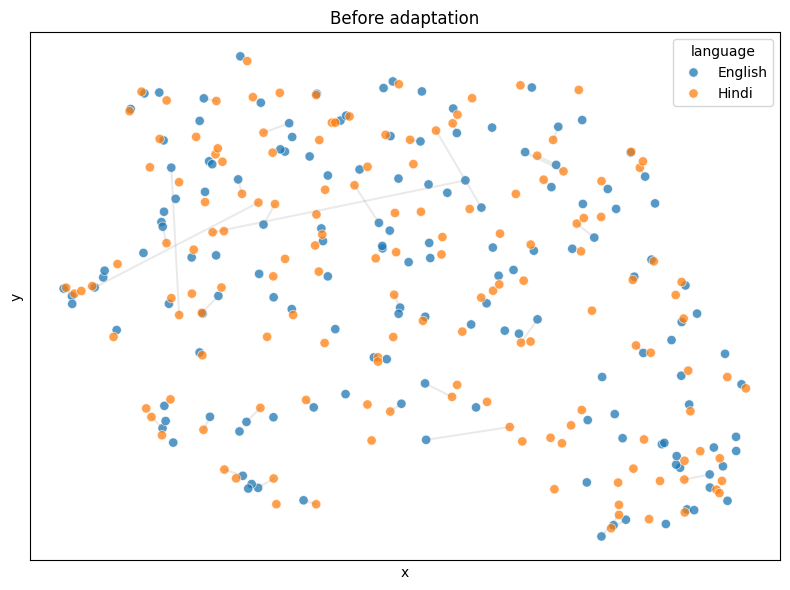

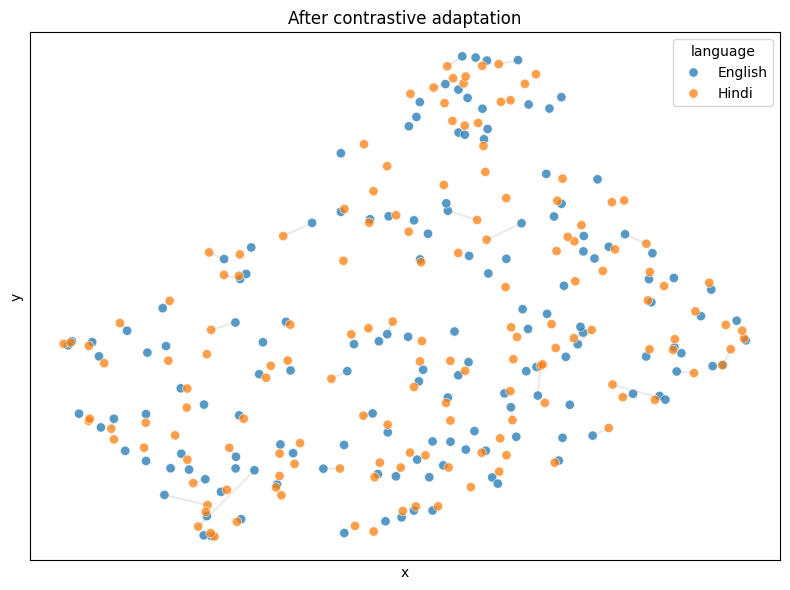

In [ ]:
def plot_alignment(details, title, n=150):
    vectors = np.vstack([details["en_emb"][:n], details["xx_emb"][:n]])
    coords = umap.UMAP(n_neighbors=15, min_dist=0.15, metric="cosine", random_state=SEED).fit_transform(vectors)
    frame = pd.DataFrame({
        "x": coords[:, 0], "y": coords[:, 1],
        "language": ["English"] * n + [LANG_NAME] * n
    })
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=frame, x="x", y="y", hue="language", alpha=0.75, s=45)
    for i in range(min(n, 40)):
        plt.plot([coords[i, 0], coords[n+i, 0]], [coords[i, 1], coords[n+i, 1]], color="gray", alpha=0.16)
    plt.title(title)
    plt.xticks([]); plt.yticks([]); plt.tight_layout()

plot_alignment(baseline_details, "Before adaptation")
plt.savefig(OUTPUT_DIR / "alignment_before.png", dpi=180, bbox_inches="tight")
plt.show()
plot_alignment(adapted_details, "After contrastive adaptation")
plt.savefig(OUTPUT_DIR / "alignment_after.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Error analysis and semantic-search demo

In [ ]:
def error_analysis(dataset, details, top_n=10):
    sim = details["sim"]
    predicted = sim.argmax(axis=1)
    ranks = details["forward_ranks"]
    worst = np.argsort(-ranks)[:top_n]
    return pd.DataFrame({
        "rank_of_gold": ranks[worst],
        "English query": [dataset[int(i)]["anchor"] for i in worst],
        "Gold translation": [dataset[int(i)]["positive"] for i in worst],
        "Retrieved translation": [dataset[int(predicted[i])]["positive"] for i in worst],
        "retrieved_score": [sim[i, predicted[i]] for i in worst],
        "gold_score": [sim[i, i] for i in worst],
    })

errors = error_analysis(test_ds, adapted_details)
display(errors)
errors.to_csv(OUTPUT_DIR / "retrieval_errors.csv", index=False)

def search_english(hindi_query, top_k=5):
    corpus = test_ds["anchor"]
    query_vec = model.encode([hindi_query], normalize_embeddings=True)
    corpus_vec = adapted_details["en_emb"]
    scores = (query_vec @ corpus_vec.T)[0]
    best = np.argsort(-scores)[:top_k]
    return pd.DataFrame({"English result": [corpus[i] for i in best], "score": scores[best]})

display(search_english("शिक्षा समाज के भविष्य के लिए महत्वपूर्ण है।"))

,rank_of_gold,English query,Gold translation,Retrieved translation,retrieved_score,gold_score
0,823,"HANNAH: Well, get on. SEAN:",CHlRPlNG],चलो चलो.,0.544920,0.031804
1,768,What reason do I have to lie?,वन और नहीं कच्चे लोहे का ढलाई खाना एक साथ रह स...,ये इस वजह से कि काफिरों ने झूठी बात की पैरवी क...,0.442347,-0.005384
2,622,- It's pretty awesome. - We'll take it.,"नहीं, यह बहुत शांत है.","वैसे, यह शानदार है!",0.626063,0.063943
3,606,S15: Keep away from heat,S15: गर्मी से दूर रखेंPlease take the official...,शून्य गर्मी.,0.459158,0.048328
4,541,That's the price of admission life hurts.,इससे तुम्हारा कोई संबंध नहीं है.,इसलिए मुझे लगता है कि मेरे आंसू दुख की वजह से ...,0.436332,0.036004
5,486,One or two days at most.,सरकार जिले भी?,"दो हफ्ते कुछ भी नहीं है, हम दो महीने में कम से...",0.629789,0.084072
6,474,Nigh unto which is the Garden of Abode.,उसी के पास तो रहने की बेहिश्त है,Landover पार्क.,0.494830,0.081908
7,453,♪ I only know it's a matter of time ♪,"तुम बेकार, गिरे हुए इंसान!",यह केवल समय है - आईटी पहली बार है,0.579436,0.172692
8,444,We can't lose him! My God!,"आप वास्तव में, बच्चों के रूप में उन्हें देख नह...",वे दूर नहीं मिलेगा!,0.521538,0.122845
9,444,"Thanks a lot, Bin Laden.",क्या कोई payphone बैंक?,- धन्यवाद.,0.656469,0.122713


,English result,score
0,Gifts and sweets were distributed among the st...,0.288149
1,"""We aspire to a better tomorrow, a new Egypt a...",0.258916
2,Tomorrow %l:%M:%S %p,0.249823
3,"Mm-hm, but if we teamed up, it could bring you...",0.243017
4,With festivals can food be far behind? .:Myfri...,0.232818


## 8. Save reproducible artifacts

In [ ]:
results.to_csv(OUTPUT_DIR / "metrics.csv", index=False)
run_config = {
    "language": LANG_NAME,
    "language_code": LANG,
    "dataset": "Helsinki-NLP/opus-100",
    "dataset_config": DATASET_CONFIG,
    "base_model": MODEL_NAME,
    "train_size": TRAIN_SIZE,
    "dev_size": DEV_SIZE,
    "test_size": TEST_SIZE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "mean_r1_improvement_percentage_points": improvement,
}
with open(OUTPUT_DIR / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2)

archive = shutil.make_archive("low_resource_embedding_project", "zip", OUTPUT_DIR)
print("Created:", archive)

from google.colab import files
files.download(archive)

Created: /content/low_resource_embedding_project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>